### K-Means Clustering

**Core idea**  
K-Means groups data into `k` clusters by minimizing the distance between data points and their assigned cluster centroids.  
It works in both low (2D) and high-dimensional spaces in the same way.

---

**Key question**  
How do we decide clusters in high dimensions?

- In practice, the number of clusters `k` is assumed or determined using methods like Elbow or Silhouette  
- For now, assume `k = 3`

---

**Algorithm steps**

1. Decide number of clusters `k`  

2. Initialize centroids  
   - Randomly select `k` points as initial centroids  

3. Assign clusters  
   - For each data point:
     - Compute distance to all centroids (Euclidean distance)  
     - Assign the point to the nearest centroid  

4. Move centroids  
   - For each cluster:
     - Compute new centroid = mean of all points in that cluster  
   - This updates cluster centers  

5. Check convergence  
   - If centroids do not change → stop  
   - Otherwise → repeat steps 3 and 4  

---

**Important insight**

Steps 3 (assignment) and 4 (update) are the core of the algorithm and are repeated iteratively until convergence.

---

**Geometric intuition**

- Clusters are formed based on distance  
- Centroids move toward dense regions of data  
- Final clusters represent locally optimal groupings  

---

**High-dimensional understanding**

- Same logic applies as in 2D  
- Distance is computed across all features  
- Visualization is harder, but computation remains identical  

---

**One-line revision**

K-Means iteratively assigns points to nearest centroids and updates centroids until convergence.

### K-Means Clustering + Elbow Method 

**Core idea**  
K-Means groups data into `k` clusters by minimizing the distance between data points and their assigned centroids.  
It works the same way in both low (2D) and high-dimensional spaces.

---

### Data perspective (important)

- ML does not “see” images or objects  
- It works on **numbers**  
- Example: an image (28×28) → 784 features  
- Each data point = a vector in high-dimensional space  

Clustering is done based on **distance between these vectors**

---

### Algorithm steps

1. Decide number of clusters `k`  

2. Initialize centroids  
   - Randomly choose `k` points as centroids  

3. Assign clusters  
   - For each data point:
     - Compute distance to all centroids (Euclidean)  
     - Assign to nearest centroid  

4. Move centroids  
   - For each cluster:
     - Compute new centroid = mean of all points in that cluster  

5. Check convergence  
   - If centroids do not change → stop  
   - Else repeat steps 3 and 4  

---

### Key insight

Steps 3 and 4 are the backbone:
- Assignment depends on centroids  
- Centroids depend on assignment  
- This loop continues until convergence  

---

### Objective function (WCSS / Inertia)

:contentReference[oaicite:0]{index=0}

- Measures how compact clusters are  
- Lower value = better clustering  

---

### High-dimensional intuition

- Same logic as 2D  
- Distance computed across all features  
- Visualization is hard, but math is identical  

---

### Choosing number of clusters (Elbow Method)

**Problem**  
We must choose `k` manually  

---

### Step-by-step

1. Select range of `k` (e.g., 1 to 10 or 15)

2. For each `k`:
   - Run K-Means  
   - Compute WCSS  

3. Store results:

```text
k = 1 → WCSS₁  
k = 2 → WCSS₂  
k = 3 → WCSS₃  
...

### Behavior of WCSS

- WCSS₁ > WCSS₂ > WCSS₃ > WCSS₄ ...  
- As `k` increases → WCSS decreases  

Extreme case:  
- `k = number of data points` → WCSS ≈ 0  

---

### Elbow Curve

- X-axis → number of clusters (`k`)  
- Y-axis → WCSS  

Curve pattern:
- Sharp decrease initially  
- Then gradual flattening  

---

### Selecting optimal k

Choose the **elbow point**

- Point where:
  - Rate of decrease slows down  
  - Curve becomes less steep  

Analogy:
- Like an object falling fast → then slowing down  

---

### Practical limitations

- Elbow is sometimes not clearly visible  
- May require additional methods:
  - Silhouette Score  
  - Domain knowledge  

---

### Common issues in K-Means

- Sensitive to initialization  
- Affected by outliers  
- Assumes spherical clusters  
- Requires feature scaling  

---

### Final takeaway

K-Means is an iterative distance-based clustering algorithm, and the Elbow method helps choose the optimal number of clusters by identifying the point where adding more clusters gives diminishing returns.

## Example 

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

from sklearn.datasets import make_blobs

In [3]:
X, y = make_blobs(
    n_samples=300,
    centers=5,          
    cluster_std=1.2,  
    random_state=42
)

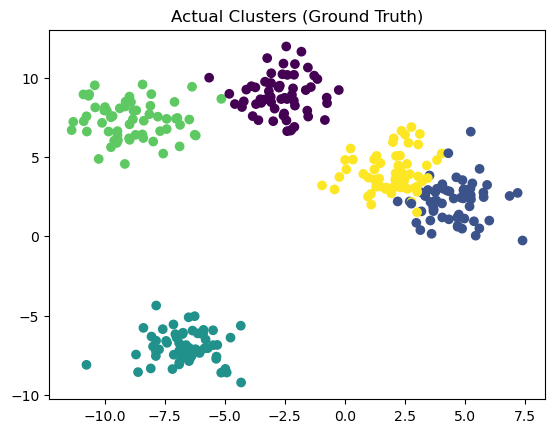

In [4]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Actual Clusters (Ground Truth)")
plt.show()

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [9]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) 

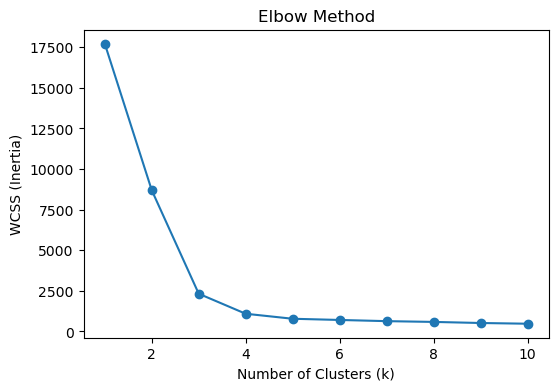

In [10]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")

plt.show()

> from graph Optimal number of clusters = 3

In [13]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)

y_means = km.fit_predict(X)
centroids = km.cluster_centers_

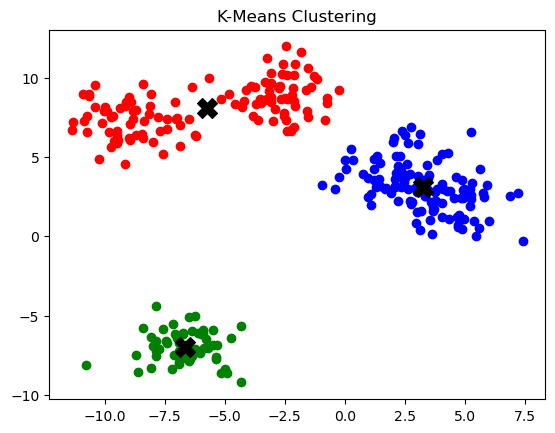

In [14]:
plt.scatter(X[y_means == 0, 0], X[y_means == 0, 1], color='blue')
plt.scatter(X[y_means == 1, 0], X[y_means == 1, 1], color='red')
plt.scatter(X[y_means == 2, 0], X[y_means == 2, 1], color='green')
plt.scatter(X[y_means == 3, 0], X[y_means == 3, 1], color='yellow')


plt.scatter(centroids[:,0], centroids[:,1], color='black', marker='X', s=200)

plt.title("K-Means Clustering")
plt.show()

## K-Means on 3D Data

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from mpl_toolkits.mplot3d import Axes3D

In [16]:
X, y_true = make_blobs(
    n_samples=300,
    centers=3,
    n_features=3,   
    cluster_std=1.5,
    random_state=42
)

In [17]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

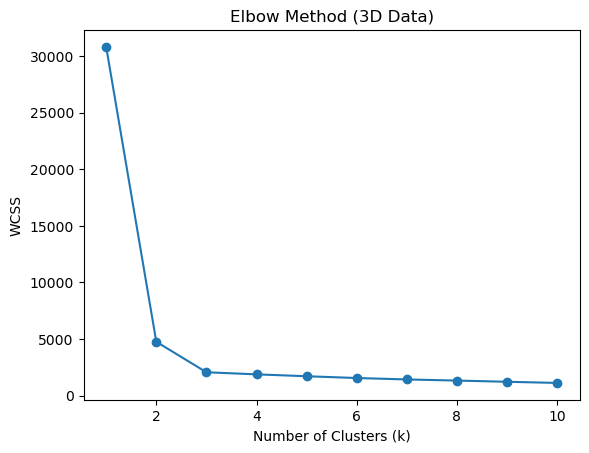

In [18]:
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method (3D Data)")

plt.show()

> Optimal number of clusters = 3

In [19]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

y_means = kmeans.fit_predict(X)
centroids = kmeans.cluster_centers_

In [22]:
import pandas as pd
import plotly.express as px

df_plot = pd.DataFrame(X, columns=["x", "y", "z"])
df_plot["cluster"] = y_means.astype(str)

In [23]:
fig = px.scatter_3d(
    df_plot,
    x="x",
    y="y",
    z="z",
    color="cluster",
    title="K-Means Clustering (3D)"
)

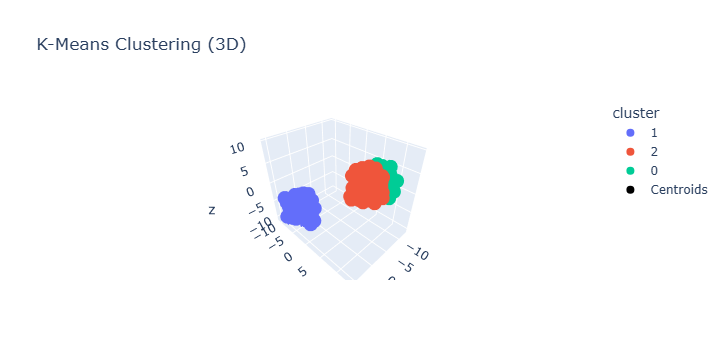

In [24]:
import plotly.graph_objects as go

fig.add_trace(go.Scatter3d(
    x=centroids[:, 0],
    y=centroids[:, 1],
    z=centroids[:, 2],
    mode='markers',
    marker=dict(size=8, color='black'),
    name='Centroids'
))
fig.show()